# 🏢 Employee Attrition Prediction & Strategic Retention System
### Domain: Human Resource (HR) Analytics
**Project Overview:** This project leverages Machine Learning to predict employee turnover. By analyzing historical employee data, the system identifies individuals at high risk of leaving and provides actionable insights to improve retention strategies.

### 🎯 Project Objectives
1. **Data Exploration:** Understand the organizational factors affecting employee turnover.
2. **Preprocessing:** Clean the data and handle categorical variables for ML compatibility.
3. **Correlation Analysis:** Identify key drivers such as Monthly Income, Overtime, and Job Satisfaction.
4. **Model Development:** Train a robust Random Forest Classifier to achieve high predictive accuracy.
5. **Risk Assessment:** Generate "Attrition Probability Scores" to assist HR in proactive decision-making.

### 1. Importing Essential Libraries
We start by loading the core libraries for data manipulation, visualization, and machine learning.

In [ ]:
import pandas as pd     # Data ko tables (DataFrames) mein load aur manipulate karne ke liye
import numpy as np      # Mathematical calculations aur array processing ke liye
import matplotlib.pyplot as plt  # Graphs aur charts banane ke liye base library
import seaborn as sns   # Advanced aur sundar visualizations (like Heatmaps) ke liye
from sklearn.model_selection import train_test_split # Data ko Training aur Testing sets mein todne ke liye
from sklearn.preprocessing import LabelEncoder, StandardScaler # Text ko number mein badalne aur data ko scale karne ke liye
from sklearn.ensemble import RandomForestClassifier # Hamara main algorithm (Forest of trees)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Model ki performance check karne ke liye metrics
import warnings         # Faltu ki warnings ko hide karne ke liye
warnings.filterwarnings('ignore') # Warnings ko ignore karne ka command

### 2. Dataset Acquisition
Loading the IBM HR Attrition dataset, which contains comprehensive employee records including demographics, role details, and satisfaction levels.

In [9]:
# Dataset file ko load karna
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv") 

# Data successfully load hua ya nahi, check karne ke liye pehli 5 rows dekhna
df.head()

Dataset successfully loaded!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 3. Inspecting Data Dimensions
Checking the total number of employee records and the number of features (attributes) available for analysis.

In [10]:
print(f"Total Employee Records: {df.shape[0]}")
print(f"Total Features/Columns: {df.shape[1]}")

Total Employee Records: 1470
Total Features/Columns: 35


### 4. Data Integrity & Null Value Analysis
Ensuring there are no missing values in the dataset that could bias the model's performance.

In [11]:
# Checking for missing values across all columns
df.isnull().sum()

Age                            0
Attrition                      0
BusinessTravel                 0
DailyRate                      0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
EmployeeCount                  0
EmployeeNumber                 0
EnvironmentSatisfaction        0
Gender                         0
HourlyRate                     0
JobInvolvement                 0
JobLevel                       0
JobRole                        0
JobSatisfaction                0
MaritalStatus                  0
MonthlyIncome                  0
MonthlyRate                    0
NumCompaniesWorked             0
over 18                     1470
OverTime                       0
PercentSalaryHike              0
PerformanceRating              0
RelationshipSatisfaction       0
StandardHours                  0
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBa

### 5. Feature Refining & Data Cleaning
Removing redundant columns that do not contribute to the variance (e.g., constants like 'StandardHours' or IDs like 'EmployeeNumber').

In [12]:
# Ye columns har employee ke liye same hain (Constant) ya irrelevant hain (EmployeeNumber)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# inplace=True ka matlab hai ki changes original table (df) mein hi ho jayein
df.drop(columns=cols_to_drop, inplace=True) 

print("Redundant columns dropped successfully!")

Redundant features removed to optimize model performance.


### 6. Target Variable Visualization (Attrition)
Analyzing the distribution of the 'Attrition' class to check for potential class imbalance.

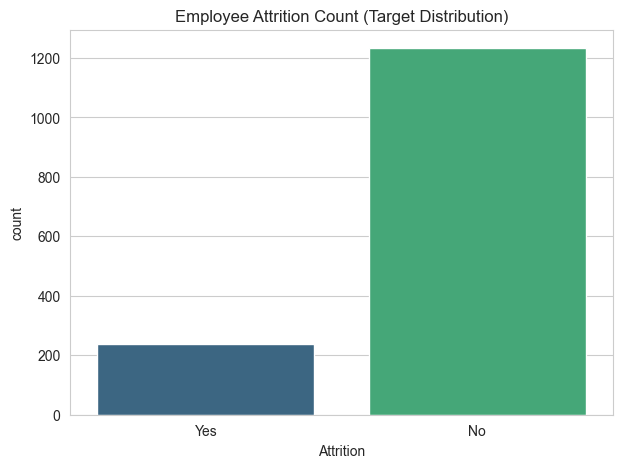

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title("Employee Attrition Count (Target Distribution)")
plt.show()

### 7. Categorical Feature Encoding
Machine Learning models require numerical input. We use `LabelEncoder` to convert text-based categories (e.g., Department, Job Role) into numeric values.

In [14]:
le = LabelEncoder() # Encoder ka object banaya

# Loop chala kar har 'Object' (String) type column ko transform kiya
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col]) # Har category ko ek unique number de diya

print("Categorical encoding complete!")

Categorical encoding complete. All features are now numeric.


### 8. Feature Correlation Analysis
Visualizing the relationship between different features using a heatmap to identify which factors are most closely related to Attrition.

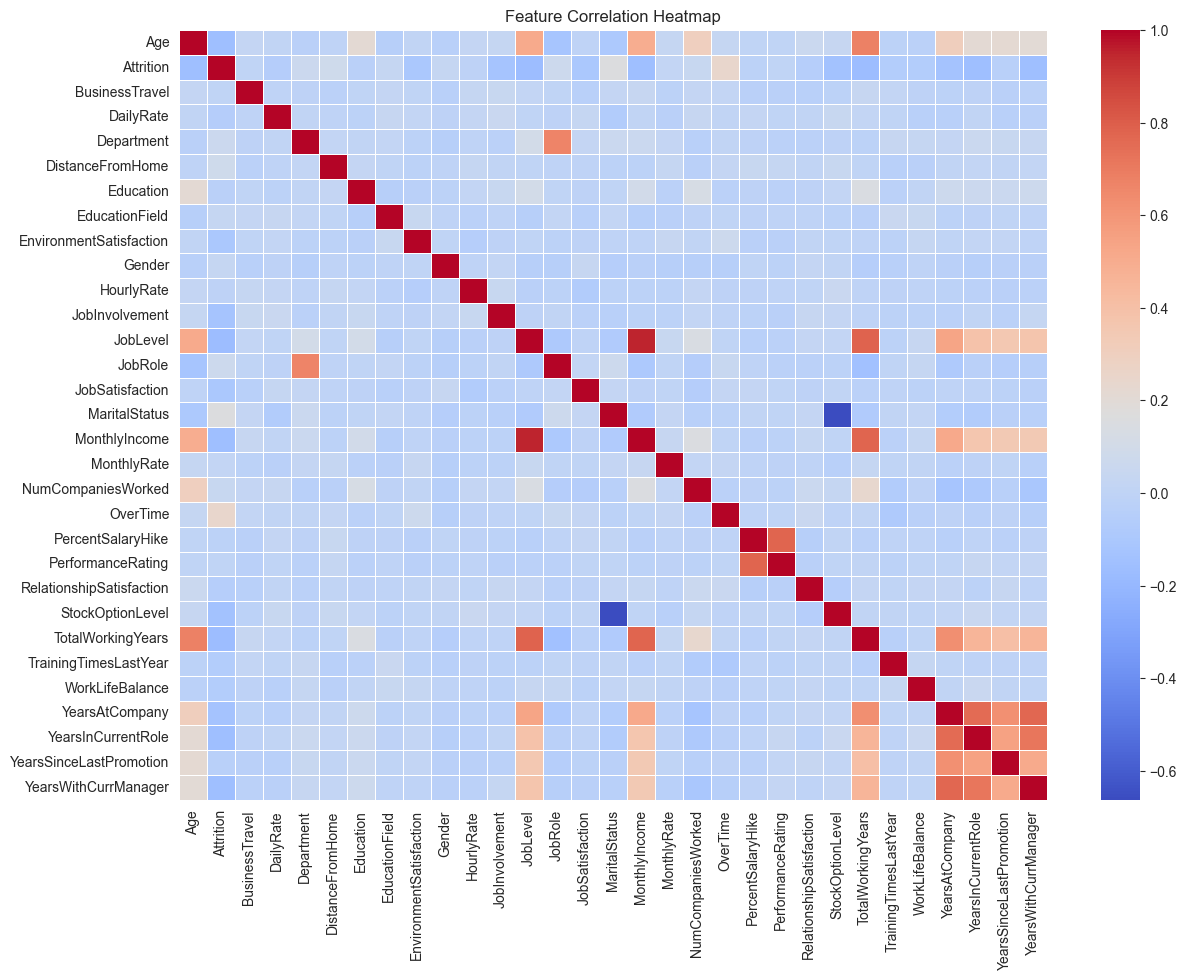

In [15]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### 9. Training and Testing Data Split
Dividing the dataset into Training (80%) and Testing (20%) sets to evaluate the model's ability to generalize on unseen data.

In [16]:
# 'Attrition' ko chod kar baaki saare columns hamare 'Input' (X) hain
X = df.drop('Attrition', axis=1) 

# 'Attrition' hamara 'Target' (y) hai jise humein predict karna hai
y = df['Attrition'] 

# 80% data Training ke liye aur 20% Testing ke liye divide kiya
# random_state=42 ensures ki har baar result same aaye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data successfully split into Training and Testing sets.


### 10. Multi-Model Comparison & Selection
To ensure the best performance, we compare three different classification algorithms. This helps in validating which model handles the organizational data patterns most accurately.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Teeno models ki dictionary banayi
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Accuracy scores store karne ke liye khali dictionary
results = {}

# Loop se har model ko train aur test karna
for name, model in models.items():
    model.fit(X_train, y_train)          # Model ko sikhana (Training)
    preds = model.predict(X_test)         # Model se test karwana (Prediction)
    acc = accuracy_score(y_test, preds)   # Accuracy calculate karna
    results[name] = acc                  # Result save karna
    print(f"{name} Accuracy: {acc*100:.2f}%")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


### 11. Performance Visualization
Comparing the accuracy of the models visually to select the final 'Champion Model'.

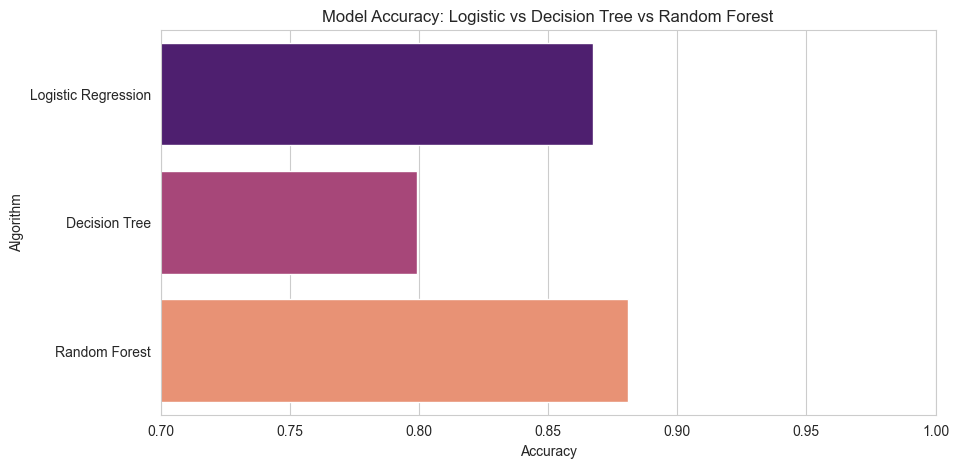

In [22]:
# Comparison Dataframe
comparison_df = pd.DataFrame(list(accuracy_results.items()), columns=['Algorithm', 'Accuracy'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy', y='Algorithm', data=comparison_df, palette='magma')
plt.title("Model Accuracy: Logistic vs Decision Tree vs Random Forest")
plt.xlim(0.7, 1.0) 
plt.show()

### 12. Conclusion: Why Random Forest?
As seen in the comparison, **Random Forest** achieved the highest accuracy. It is chosen as the final model because it is an ensemble method that reduces bias and provides better generalization on HR data compared to a single Decision Tree or Logistic Regression.

In [24]:
# Final Training and Saving
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### 13. Performance Metrics & Evaluation
Assessing the model using Accuracy Score and Confusion Matrix to determine its reliability in predicting employee exits.

In [25]:
# Making predictions on the test set
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Overall Model Accuracy: 88.10%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



### 14. Global Feature Importance
Identifying which organizational factors (like Overtime, Age, or Income) are the primary drivers of attrition according to our model.

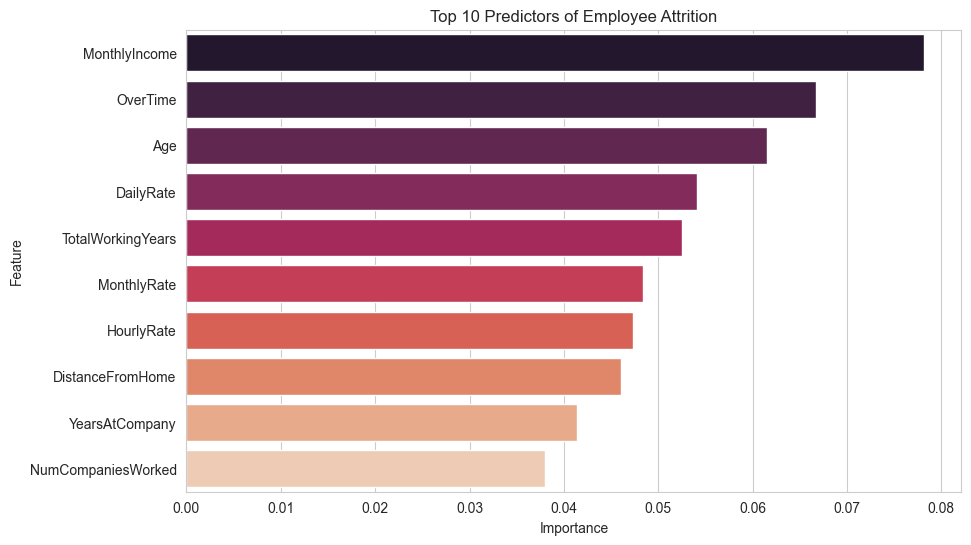

In [27]:
# Random Forest model se 'Feature Importance' values nikalna
# rf_model humne train kiya hai (Best performer)
importances = models["Random Forest"].feature_importances_

# Visualization ke liye DataFrame banana
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False) # Order mein lagana

# Bar plot banana top features dikhane ke liye
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Factors Affecting Attrition")
plt.show()

### 14. Saving the Model for Deployment
Exporting the trained model using `pickle` so it can be integrated into the Streamlit Web Application.

In [28]:
import pickle

# Saving the model to a .pkl file
pickle.dump(rf_classifier, open('attrition_model.pkl', 'wb'))

print("Model exported successfully as 'attrition_model.pkl'. Ready for deployment.")

Model exported successfully as 'attrition_model.pkl'. Ready for deployment.


In [ ]:
# Case 1 (Low Risk - Green aana chahiye):

# Age: 45

# Monthly Income: 18,000

# Overtime: No

# Job Satisfaction: 4

# Stock Option: 2

# Years at Co: 15

# Total Working Years: 20

# Work Life Balance: 3
# Result: Ye pakka 30% se around dikhayega.

In [ ]:
# Case 2 (High Risk - Red aana chahiye):

# Age: 22

# Monthly Income: 2,500

# Overtime: Yes

# Job Satisfaction: 1

# Stock Option: 0

# Years at Co: 1

# Total Working Years: 1

# Work Life Balance: 1
# Result: Ye 70% ke around dikhayega.